In [1]:
import numpy as np
import matplotlib.pyplot as plt

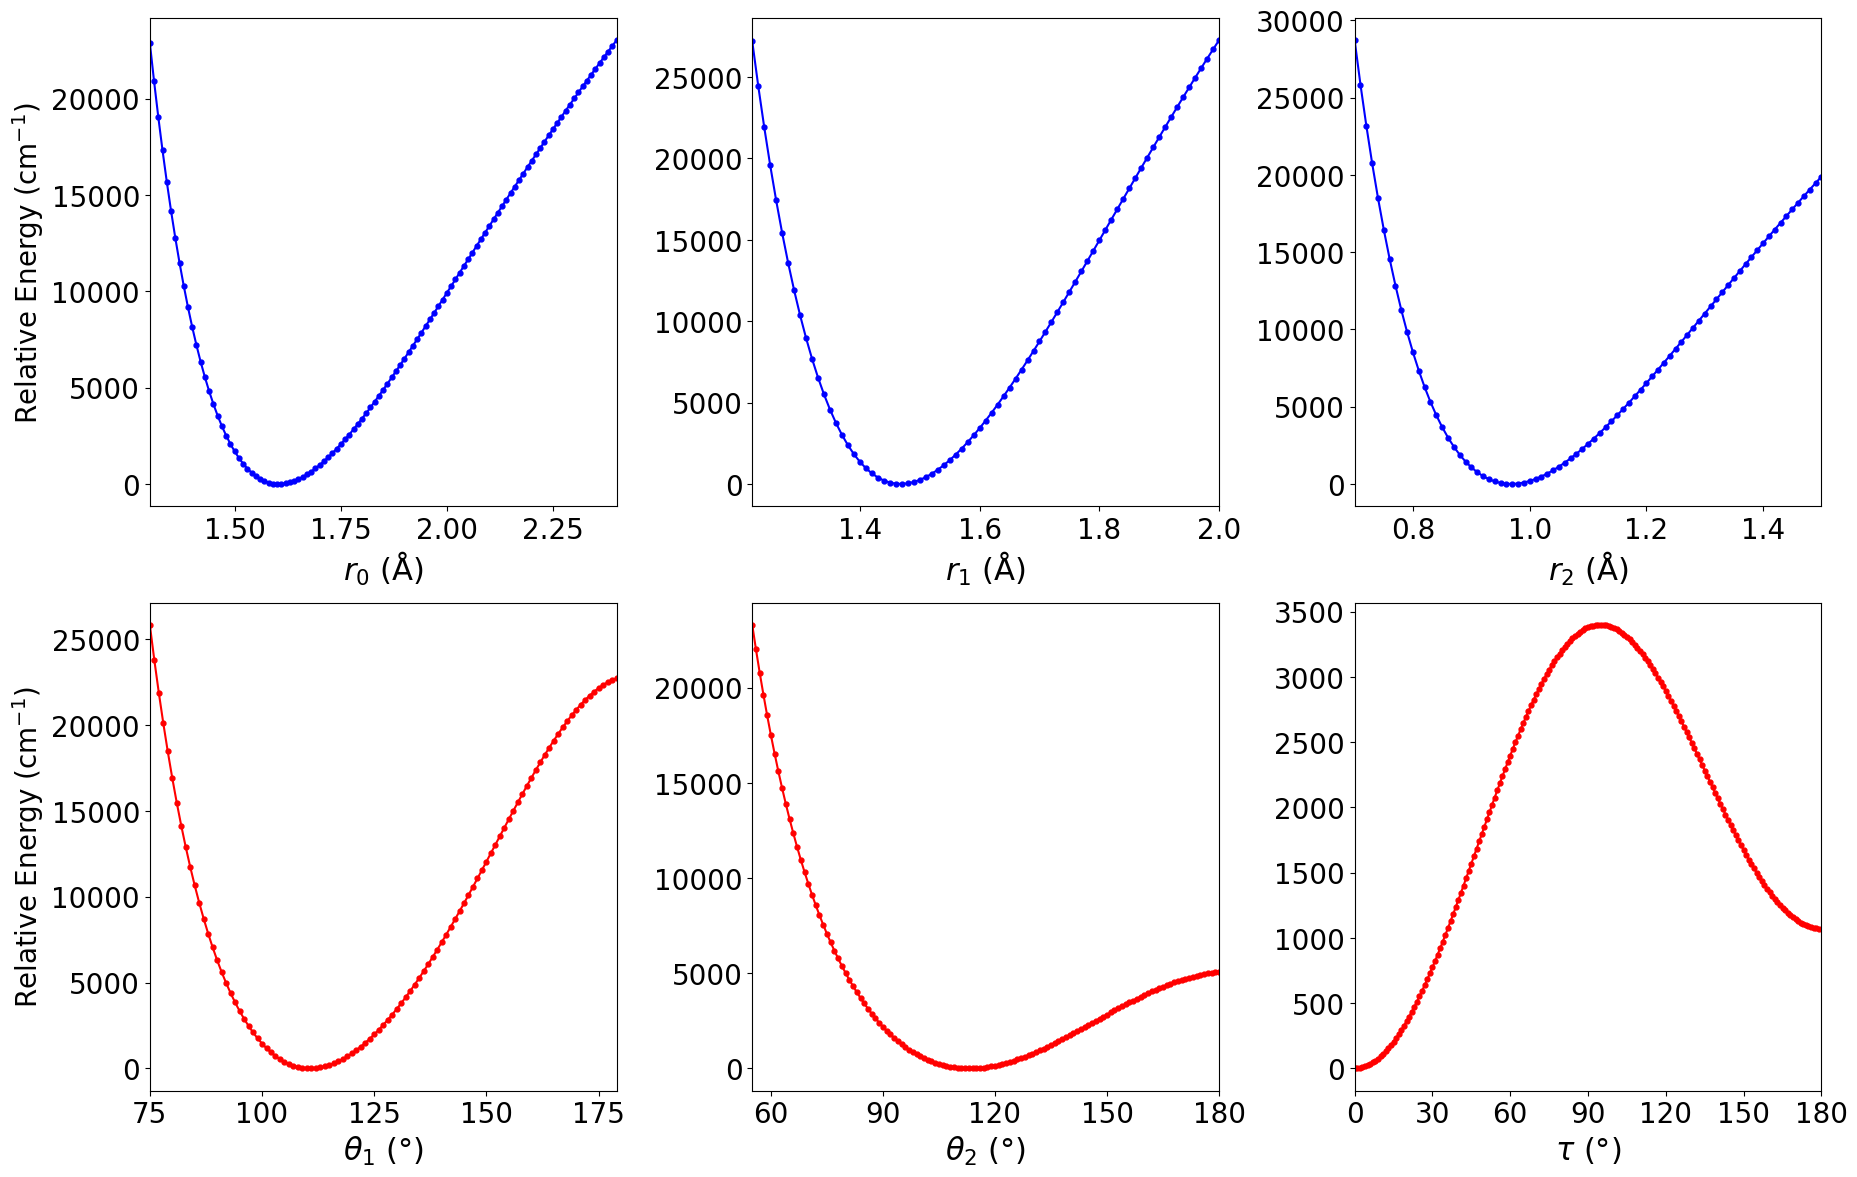

In [32]:
pVQZ_vals = np.loadtxt('1D_pVQZ.txt', delimiter='\t')
hartree_to_cm = 219474.6313705
minimum = -491.9191405575
pVQZ_vals[:,6] = (pVQZ_vals[:,6] - np.min(pVQZ_vals[:,6]))*hartree_to_cm


xlabels = [r'$r_1$',r'$r_0$',r'$r_2$', r'$\theta_1$', r'$\theta_2$', r'$\tau$']
x_units = ['Å','Å','Å', '°', '°', '°']
coord_idx = [0, 1, 2, 3, 4, 5]
idx = np.array([0,79,190,271,376,502,682])

coordinate_lower_bounds = [1.3, 1.22,  0.77, 77, 57, 0]
coordinate_upper_bounds = [2.4, 2.0, 1.5, 180, 180, 180]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes[0,0], axes[0,1] = axes[0,1], axes[0,0] #swap which coordinate is r0 and r1
fig.subplots_adjust(hspace=0.15, wspace=0.1)

for plot_num, j in enumerate(coord_idx):
    ax = axes[plot_num // 3, plot_num % 3]
    x_coordinate = pVQZ_vals[idx[j]:idx[j+1], j]
    energy = pVQZ_vals[idx[j]:idx[j+1], 6]

    plot_color = 'blue'
    if j > 2: 
        plot_color = 'red'

    ax.plot(x_coordinate, energy, markersize=18, color=plot_color)
    ax.plot(x_coordinate, energy, '.', markersize=7, color=plot_color)
    ax.set_xlim(min(x_coordinate), max(x_coordinate))

    ax.set_xlabel(f'{xlabels[j]} ({x_units[j]})', fontsize=22)
    ax.tick_params(labelsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.99])
axes[1, 1].set_xticks(range(60, 181, 30))
axes[1, 2].set_xticks(range(0, 181, 30))
axes[0, 1].set_ylabel(r'Relative Energy (cm$^{-1}$)', fontsize=20)
axes[1, 0].set_ylabel(r'Relative Energy (cm$^{-1}$)', fontsize=20)

plt.savefig(fname='1d_cuts_pes_pvqz.eps', 
            format='eps', 
            orientation='Portrait',  
            transparent=False, 
            bbox_inches="tight",
            pad_inches=0)
plt.show()